# Introdução  

Este notebook apresenta um fluxo simples e prático de **Processamento de Linguagem Natural (PLN)** em Python. O objetivo é mostrar, passo a passo, como transformar texto em representações numéricas (vetores), medir similaridade entre documentos e visualizar resultados de forma exploratória.  


# 1. Importação de Bibliotecas e Preparação do Ambiente

Nesta etapa, realizamos a **importação das principais bibliotecas** que serão utilizadas ao longo do notebook de Processamento de Linguagem Natural (PLN).  

- **Pandas e Numpy**: manipulação e análise de dados.  
- **NLTK (Natural Language Toolkit)**: ferramentas para processamento de texto em língua natural (remoção de *stopwords*, stemming, etc.).  
- **Scikit-learn**: contém implementações de vetorização (BoW e TF-IDF), métricas de similaridade e redução de dimensionalidade.  
- **Matplotlib e Seaborn**: visualizações gráficas dos dados e resultados.  

Além disso, é feito o **download de recursos adicionais do NLTK**, como a lista de *stopwords* em português, necessária para pré-processamento textual. Esse download é executado apenas uma vez no ambiente.

In [1]:
# 1. Importação de Bibliotecas e Preparação do Ambiente

import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Download de recursos da NLTK (necessário apenas na primeira execução)
try:
    stopwords.words('portuguese')
except LookupError:
    nltk.download('stopwords')

nltk.download('rslp')



[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\SANCES_502\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

# 2. Definição do Corpus e da Consulta

Nesta etapa, construímos a base de dados textual que será utilizada para os experimentos.  

- **Corpus**: é o conjunto de documentos (aqui representados por frases curtas) que servirão como fonte de informação. Cada elemento da lista corresponde a um "documento".  
- **Consulta (query)**: é a frase que usaremos como referência para buscar documentos semanticamente similares dentro do corpus.  

O corpus, neste exemplo, contém frases simples sobre gatos e cachorros, o que facilita a compreensão dos métodos de representação e comparação textual.  
A consulta escolhida foi: **"cachorro brincalhão"**, que nos permitirá verificar como diferentes técnicas de vetorização capturam proximidade semântica com os documentos.


In [2]:
# 2. Definição do Corpus e da Consulta
import csv
import ast
df = pd.read_csv("todas_as_praias_lemmatized.csv", encoding="utf-8-sig")
# corpus = df["title_stemming"].apply(ast.literal_eval).apply(lambda x: " ".join(x))

# um documento por review, com título e texto juntos
corpus = (
    df["title_stemming"].apply(ast.literal_eval).apply(lambda x: " ".join(x))
    + " " +
    df["text_stemming"].apply(ast.literal_eval).apply(lambda x: " ".join(x))
)

query = "praia bonita"

corpus

0       otim cidad passei famil cidad tranquil boa pra...
1       prai abandon prai suj mal cuid lix espalh orl ...
2       car fic prai impropr banh lug aconcheg por pre...
3       tarden prai alegr prai legal ir famil mar calm...
4       potenc so precis atenca pod publ frequent cida...
                              ...                        
6207    pra saudad prai nunc esquec pra tud bars mar e...
6208    ond fort qu prai ond fort agit va pra gost pou...
6209    surf pequen prai pertenc sao francisc sul rece...
6210    surf tod dia pra conhec palc grand competico s...
6211    prai saudad melhor sao francisc sul mim melhor...
Length: 6212, dtype: object

# 3. Pipeline de Pré-processamento

Antes de aplicar técnicas de vetorização, precisamos padronizar o texto para reduzir variações linguísticas e ruídos.  

As etapas principais são:  

- **Stemming**: reduz cada palavra ao seu radical (ex.: *cachorros* → *cachorr*), o que diminui a dimensionalidade do vocabulário.  
- **Stopwords**: palavras muito frequentes e de baixo valor semântico (como "de", "a", "o") são removidas.  

Também aplicamos o stemming à lista de *stopwords*. Isso garante consistência, já que o corpus passará pelo mesmo processo.  

Por fim, definimos uma função de **tokenização personalizada** (`stem_tokenizer`), responsável por:  
1. Quebrar o texto em tokens (palavras).  
2. Aplicar o stemming em cada token.  
3. Retornar a lista de radicais, pronta para ser usada pelos vetorizadores.


In [3]:
# 3. Pipeline de Pré-processamento

# Instancia o stemmer para o português
stemmer = RSLPStemmer()

# Carrega a lista de stopwords original da NLTK
portuguese_stop_words_original = stopwords.words('portuguese')

stop_words_stemmed = [stemmer.stem(word) for word in portuguese_stop_words_original]


# Define a função de tokenização que aplica a radicalização (stemming)
# Esta função será passada para os vetorizadores.
def stem_tokenizer(text):
    tokens = text.split()
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return stemmed_tokens



# 4. Vetorização com Bag of Words (BoW)

Agora transformamos o corpus em uma **matriz numérica** utilizando o modelo **Bag of Words (BoW)**.  

- **Bag of Words**: representa cada documento por um vetor de frequências, em que cada coluna corresponde a um termo do vocabulário.  
- Parâmetros importantes:  
  - `lowercase=True`: converte todo o texto para letras minúsculas.  
  - `stop_words=stop_words_stemmed`: utiliza a lista de *stopwords* já processada com stemming.  
  - `tokenizer=stem_tokenizer`: aplica nossa função de tokenização personalizada.  

O resultado é a **Matriz Documento-Termo**, onde cada linha representa um documento e cada coluna corresponde a um termo do vocabulário.  

---

### Sobre os *warnings* recebidos

1. **Aviso sobre `token_pattern`:**  
   > *"The parameter 'token_pattern' will not be used since 'tokenizer' is not None"*  
   Esse aviso é esperado, pois definimos nossa própria função de tokenização (`stem_tokenizer`). O `token_pattern` interno do `CountVectorizer` é ignorado, mas isso **não é um erro**.

2. **Aviso sobre inconsistência das stopwords:**  
   > *"Your stop_words may be inconsistent with your preprocessing..."*  
   Esse alerta aparece porque algumas *stopwords* originais do NLTK, após o stemming, não coincidem exatamente com os tokens gerados na tokenização.  
   - Na prática, isso **não compromete os resultados**, mas pode ser minimizado ao revisar manualmente a lista de *stopwords* ou gerar a lista de *stopwords* já stemmatizadas diretamente a partir do corpus.

---

Conclusão: os *warnings* não impedem o funcionamento correto do modelo e podem ser tratados como informativos.


In [4]:
# 4. Vetorização com Bag of Words (BoW)
import ast

# df["title_stemming"].apply(ast.literal_eval)

#
bow_vec = CountVectorizer(
    lowercase=True,
    stop_words=stop_words_stemmed,   # ✅ stopwords corretas
    tokenizer=stem_tokenizer
)
X_bow = bow_vec.fit_transform(corpus)
df_bow = pd.DataFrame(X_bow.toarray(), columns=bow_vec.get_feature_names_out())

print("Matriz Documento-Termo (BoW):")
df_bow


C:\Users\SANCES_502\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:523: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\SANCES_502\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['es', 'estivés', 'fos', 'fôs', 'houvés', 'is', 'nos', 'tivés'] not in stop_words.
  warnings.warn(


Matriz Documento-Termo (BoW):


,'m,'na,'pr,'propr,'s,+-3.000,",chuv",",var",-a,-com,...,👏👏👏👏👏,😁,😂😂,😉,😍,😘,😜😜🙏🙏🙏🙏🙏,😢,😦😦,🥰🏖
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6207,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6208,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6209,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6210,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 5. Vetorização com TF-IDF

Nesta etapa, utilizamos a técnica **TF-IDF (Term Frequency – Inverse Document Frequency)** para representar os documentos numericamente.  

- **TF (Frequência do termo):** quantas vezes uma palavra aparece em um documento.  
- **IDF (Frequência inversa do documento):** mede a importância da palavra em relação a todo o corpus. Palavras muito frequentes (ex.: “o”, “de”) recebem menor peso, enquanto termos mais raros são valorizados.  
- **TF-IDF = TF × IDF:** resultado final é um vetor ponderado que reflete a relevância de cada termo em cada documento.  

Assim como no BoW, definimos:  
- `lowercase=True`: uniformiza o texto em minúsculas.  
- `stop_words=stop_words_stemmed`: remove as *stopwords* após stemming.  
- `tokenizer=stem_tokenizer`: garante que a tokenização e a radicalização sejam consistentes.  

O resultado é a **Matriz Documento-Termo (TF-IDF)**, onde os valores agora são **pesos normalizados** em vez de simples contagens.  
- Valores próximos de **0** → termos pouco relevantes.  
- Valores maiores → termos distintivos para aquele documento.  

---

🔎 **Diferença em relação ao BoW**:  
Enquanto o BoW considera apenas **frequência absoluta** de termos, o TF-IDF pondera pela **importância relativa** das palavras, reduzindo o impacto de termos muito comuns no corpus.


In [5]:

# 5. Vetorização com TF-IDF

tfidf_vec = TfidfVectorizer(
    lowercase=True,
    stop_words=stop_words_stemmed, # Usa a lista de stopwords corrigida
    tokenizer=stem_tokenizer
)
X_tfidf = tfidf_vec.fit_transform(corpus)
df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vec.get_feature_names_out())

print("Matriz Documento-Termo (TF-IDF):")
df_tfidf.round(3)



C:\Users\SANCES_502\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:523: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\SANCES_502\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['es', 'estivés', 'fos', 'fôs', 'houvés', 'is', 'nos', 'tivés'] not in stop_words.
  warnings.warn(


Matriz Documento-Termo (TF-IDF):


,'m,'na,'pr,'propr,'s,+-3.000,",chuv",",var",-a,-com,...,👏👏👏👏👏,😁,😂😂,😉,😍,😘,😜😜🙏🙏🙏🙏🙏,😢,😦😦,🥰🏖
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6207,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6210,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 6. Busca por Similaridade

Depois de representarmos os documentos em vetores numéricos (BoW e TF-IDF), podemos medir **o quão semelhantes** eles são em relação a uma consulta (*query*).  

Para isso, usamos a **Similaridade do Cosseno**:  
- Mede o ângulo entre dois vetores.  
- Valores próximos de **1** → documentos muito semelhantes à consulta.  
- Valores próximos de **0** → pouca ou nenhuma semelhança.  

### Passos da função `search_and_rank`:
1. **Vetoriza a query** com o mesmo método usado no corpus (BoW ou TF-IDF).  
2. **Calcula a similaridade** entre a query e todos os documentos.  
3. **Ordena os resultados** do mais relevante para o menos relevante.  
4. **Exibe o Top-3 documentos mais similares**, junto com o valor do *score*.  

---

✅ Dessa forma, conseguimos comparar como **BoW** e **TF-IDF** diferem na identificação dos documentos mais próximos da consulta `"cachorro brincalhão"`.  
Enquanto o BoW favorece termos **literalmente coincidentes**, o TF-IDF dá maior peso a termos **mais específicos e distintivos** do corpus.


In [6]:
# 6. Busca por Similaridade

def search_and_rank(query, vectorizer, X_corpus, corpus, method_name):
    """
    Vetoriza uma query, calcula a similaridade com o corpus e exibe os resultados.
    """
    q_vec = vectorizer.transform([query])
    sim_scores = cosine_similarity(q_vec, X_corpus).ravel()
    rank = np.argsort(sim_scores)[::-1]

    print(f"Top-3 Similares para a Query (usando {method_name}):")
    for i in rank[:3]:
        if sim_scores[i] > 0.01: # Apenas mostra se houver alguma similaridade
            print(f"  Doc{i+1} (score={sim_scores[i]:.3f}): {corpus[i]}")
    print("-" * 40)

print(f">> Executando busca para a query: '{query}'\n")
search_and_rank(query, bow_vec, X_bow, corpus, "BoW")
search_and_rank(query, tfidf_vec, X_tfidf, corpus, "TF-IDF")




>> Executando busca para a query: 'praia bonita'

Top-3 Similares para a Query (usando BoW):
  Doc4580 (score=0.474): bonit bonit prai bast natur gent bonit tempor lot assim br boa opca regia
  Doc3646 (score=0.442): prai bonit bonit prai passe br 101 fiz par tir uma fot lug bonit val pen conhec
  Doc699 (score=0.433): prai bonit regia prai br bonit limp frequent gal bonit balneari cambor itaj nao deix conhec
----------------------------------------
Top-3 Similares para a Query (usando TF-IDF):
  Doc1106 (score=0.420): praia boa prai bem bonit extens long orl pode-s encontr bom restaurant bar vari beach club ond acontec var fest mar agit nao recom crianc
  Doc4580 (score=0.157): bonit bonit prai bast natur gent bonit tempor lot assim br boa opca regia
  Doc699 (score=0.148): prai bonit regia prai br bonit limp frequent gal bonit balneari cambor itaj nao deix conhec
----------------------------------------


# 7. Visualizações  

## a) Heatmap da Similaridade de Cossenos entre Documentos  

Para compreender melhor as relações entre os documentos do corpus, podemos calcular a **similaridade de cossenos** entre todos eles (documento × documento).  

### Passos realizados:
1. **Cálculo da matriz de similaridade**:  
   - Utilizamos a representação TF-IDF dos documentos.  
   - A saída é uma matriz quadrada onde cada célula indica a semelhança entre dois documentos.  

2. **Criação de rótulos**:  
   - Nomeamos os documentos como `Doc1`, `Doc2`, etc., para facilitar a interpretação visual.  

3. **Visualização com Heatmap**:  
   - O **heatmap** mostra, em tons de azul, o grau de similaridade entre pares de documentos.  
   - Valores mais próximos de **1.00** (azul mais escuro) indicam alta semelhança.  
   - Valores próximos de **0.00** (azul claro) indicam baixa ou nenhuma semelhança.  

---

Esse tipo de visualização é útil para **detectar agrupamentos de documentos** que compartilham vocabulário e temas semelhantes, permitindo interpretar rapidamente a estrutura semântica do corpus.


Calculando a matriz de similaridade de cossenos...


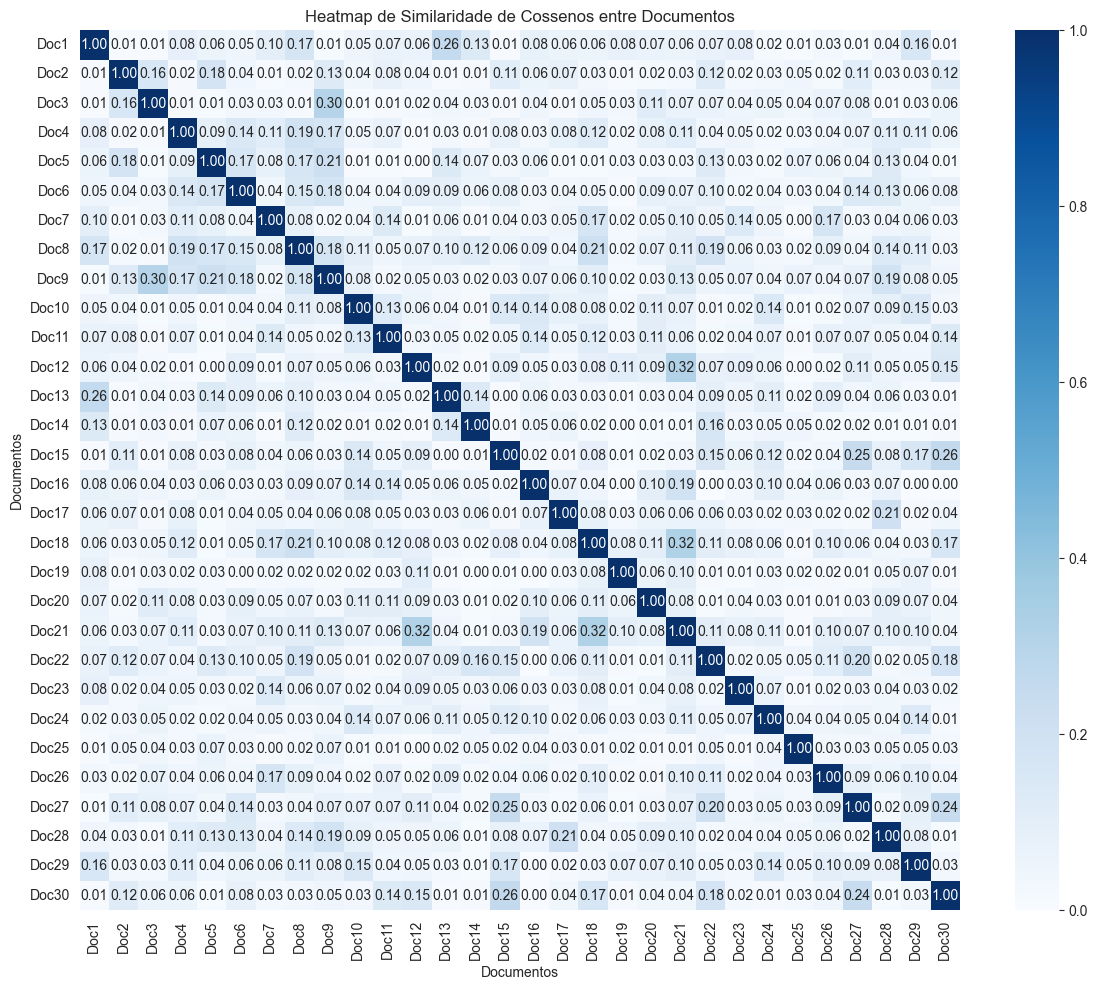

In [9]:
# 7. Visualizações

# a) Heatmap da Similaridade de Cossenos entre Documentos
# Primeiro, calculamos a matriz de similaridade (documento x documento) usando a matriz TF-IDF
print("Calculando a matriz de similaridade de cossenos...")
# Pega só os 30 primeiros documentos para o heatmap ficar legível
amostra = 30
sim_matrix = cosine_similarity(X_tfidf[:amostra], X_tfidf[:amostra])
doc_labels = [f"Doc{i+1}" for i in range(amostra)]
df_similarity = pd.DataFrame(sim_matrix, index=doc_labels, columns=doc_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_similarity,
    annot=True,       # OK com 30 docs
    cmap="Blues",
    fmt=".2f"
)
plt.title("Heatmap de Similaridade de Cossenos entre Documentos")
plt.xlabel("Documentos")
plt.ylabel("Documentos")
plt.tight_layout()
plt.show()

## b) Visualização dos Documentos em 2D com PCA  

Outra forma de explorar as relações entre documentos é projetá-los em um **espaço bidimensional** usando **PCA (Principal Component Analysis)**.  

### O que é PCA?
- PCA é uma técnica de **redução de dimensionalidade**.  
- A ideia é comprimir vetores de alta dimensão (como aqueles gerados pelo TF-IDF) em um número menor de dimensões, preservando a maior parte da **variância** dos dados.  
- Aqui usamos **2 componentes principais**, o que permite visualizar os documentos em um plano 2D.  

### Etapas realizadas:
1. **Transformação da matriz TF-IDF**: convertida de formato esparso para uma matriz densa com `.toarray()`.  
2. **Aplicação do PCA**: reduzimos para 2 dimensões.  
3. **Plotagem em gráfico de dispersão (scatter plot)**:  
   - Cada ponto azul representa um documento do corpus.  
   - Os eixos correspondem às duas componentes principais.  
   - Os rótulos (`Doc1`, `Doc2`, etc.) ajudam a identificar cada documento no gráfico.  

---

Esse tipo de visualização é útil para **detectar agrupamentos naturais de documentos** (clusters), já que documentos semanticamente parecidos tendem a aparecer próximos no espaço 2D.


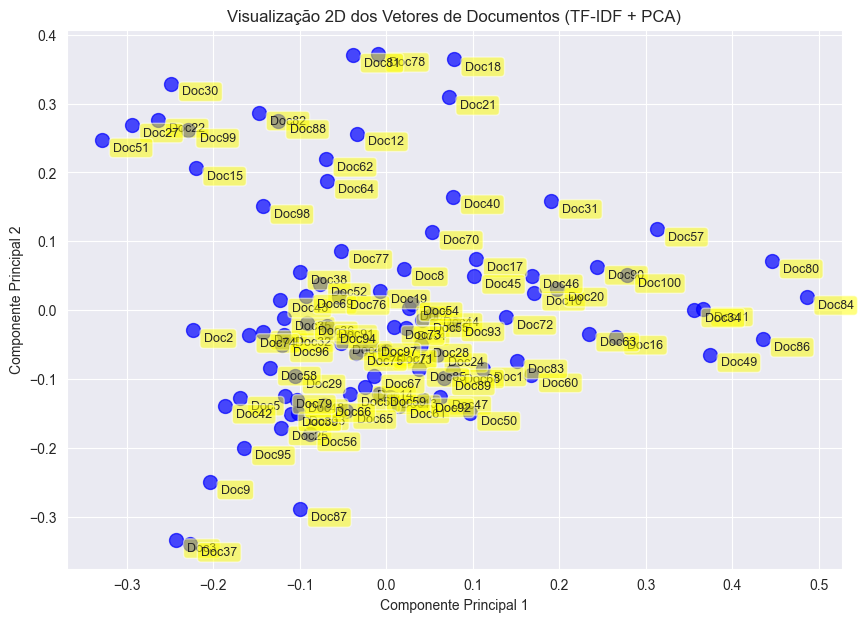

In [10]:
# b) Visualização dos Documentos em 2D com PCA
# Pega uma amostra dos dados
amostra = 100
X_amostra = X_tfidf[:amostra]  # ainda esparsa, sem .toarray()

# PCA aceita matriz esparsa diretamente com svd_solver='arpack'
from sklearn.decomposition import PCA
pca = PCA(n_components=2, svd_solver='arpack')
X_pca = pca.fit_transform(X_amostra)  # sem .toarray()

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', alpha=0.7, s=100)
plt.title("Visualização 2D dos Vetores de Documentos (TF-IDF + PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)

# Anota só os pontos da amostra — legível
for i in range(amostra):
    plt.annotate(f"Doc{i+1}", (X_pca[i, 0], X_pca[i, 1]),
                 xytext=(8, -8), textcoords='offset points', fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))
plt.show()

# Conclusão  

Neste exercício, percorremos as principais etapas de um pipeline clássico de PLN:  
- preparação e pré-processamento do texto,  
- vetorização (BoW e TF-IDF),  
- cálculo de similaridade,  
- e visualizações (heatmap e PCA).  

Para aprofundar o aprendizado, experimente modificar o código e observar como os resultados mudam:  
- **Alterar o corpus**: inclua frases sobre outros temas ou aumente o número de documentos.  
- **Mudar a query**: teste diferentes consultas e compare os rankings de documentos mais similares.  
- **Explorar pré-processamento**: remova o stemming, troque ou edite a lista de *stopwords*.  
- **Comparar técnicas**: visualize diferenças entre BoW e TF-IDF em corpora maiores ou mais variados.  

Essas variações ajudam a compreender melhor o impacto das escolhas metodológicas no desempenho das técnicas de PLN.